Plotting Initial Data, with Initial Guess


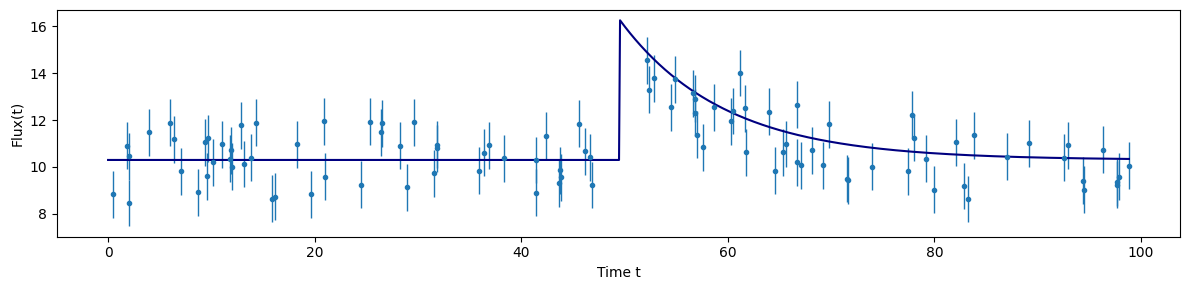

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

infile = '../solutions/transient.npy'
data = np.load(infile)
time, flux, yerr = data[:,0], data[:,1], data[:,2]
fig, axs = plt.subplots(tight_layout=True, figsize=(12,3))
axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.0, elinewidth=1); 
#_ = axs[1].hist(data[:, 1], bins=30);

Model = lambda t, bkg, bAmpl, t0, alpha: bkg if t<t0 else bkg + bAmpl*np.exp(-alpha*(t-t0))
axs.plot(np.linspace(0, max(time), 1000), [Model(t, 10.3, 6, 49.5, 0.1) for t in np.linspace(0, max(time), 1000)], c='navy')
axs.set_xlabel('Time t')
axs.set_ylabel('Flux(t)')
print('Plotting Initial Data, with Initial Guess')

In [10]:
"""
Model = lambda t, bkg, bAmpl, t0, alpha: bkg if t<t0 else bkg + bAmpl*np.exp(-alpha*(t-t0))

### Setting Priors
from scipy import stats
Prior_bkg   = lambda x: 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )
Prior_bAmpl = lambda x: 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )
Prior_t0    = lambda x: 0 if x <0 else 0 if x>100 else 1/100 #stats.uniform(loc=0, scale=100)
Prior_alpha = lambda x: stats.loguniform(a=1e-5, b=1e5).pdf(x)

Priors = [Prior_bkg, Prior_bAmpl, Prior_t0, Prior_alpha]
### ASSUMING GAUSSIAN LIKELIHOOD

def Prior(params):
    return Prior_bkg.pdf(params[0]) * Prior_bAmpl.pdf(params[1]) * Prior_t0.pdf(params[2]) * Prior_alpha.pdf(params[3])

def logPrior(params):
    y = np.log10(Prior(params))
    if np.isnan(y) == True: return -np.inf
    return y

def logPrior(params):
    return np.sum([np.log10( p(param) ) for p, param in zip(Priors, params)])
    
### Setting Likelihood
def Likelihood(params, time, flux):
    bkg, bAmpl, t0, alpha = params
    L = np.prod( [ 1 / np.sqrt( 2*np.pi*yerr[0]**2) * np.exp( -0.5/(yerr[0]**2)*(fl - Model(t, bkg, bAmpl, t0, alpha) )**2) 
                  for t, fl in zip(time, flux) ] )
    return L

### Ignoring \frac{1}{\sqrt{2 \pi \sigma^{2}}} term!
### logL \propto - \frac{ (x-\mu) ^{2}}{2\sigma^{2}}
def logLikelihood(params, time, flux):
    bkg, bAmpl, t0, alpha = params
    logL = np.sum( [ -( (f - Model(t, bkg, bAmpl, t0, alpha))**2 / 2*np.pi/rms**2 ) for t,f, rms in zip(time, flux, yerr)]  )
    if np.isnan(logL) == True: return -np.inf
    return logL

def logPosterior(params, time, flux):
    if np.isnan(logPrior(params)) == True: return -np.inf
    return logLikelihood(params, time, flux) + logPrior(params)
    
### la prior in a, b, t0 è costante -> la posso ignorare
### la prior di alpha è in log-costante -> 1/alpha
### la posterior in mcmc così, non è la posterior ma qualcosa di PROPORZIONALE alla posterior

import emcee
ndim = 4; nwalkers = 20; nsteps=10000
alphas = np.logspace(-5, 5, nwalkers)
print(alphas)
starting_guess = [ [stats.norm(11, 3).rvs(1)[0], stats.norm(5, 0.1).rvs(1)[0], stats.norm(57, 3).rvs(1)[0], stats.norm(0.1, 0.01).rvs(1)[0] ] 
                  for _ in range(nwalkers) ]
#### \theta = [ bkg, bAmpl, t0, alpha ]

### scatter starting guess on a gaussian ball around starting_guess

#p0 = Prior_bkg.pdf(np.linspace(0, 50, 1000)) * Prior_bAmpl.pdf(np.linspace(0, 50, 1000)) * Prior_t0.pdf(np.linspace(0,100,1000)) * Prior_lnalpha.pdf(np.logspace(-5, 5, 1000))
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=[time, flux])
sampler.run_mcmc(starting_guess, nsteps, progress=True)
"""

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\alfac\AppData\Local\Temp\ipykernel_9400\2549748789.py:1: SyntaxWarning: invalid escape sequence '\s'
  """


'\nModel = lambda t, bkg, bAmpl, t0, alpha: bkg if t<t0 else bkg + bAmpl*np.exp(-alpha*(t-t0))\n\n### Setting Priors\nfrom scipy import stats\nPrior_bkg   = lambda x: 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )\nPrior_bAmpl = lambda x: 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )\nPrior_t0    = lambda x: 0 if x <0 else 0 if x>100 else 1/100 #stats.uniform(loc=0, scale=100)\nPrior_alpha = lambda x: stats.loguniform(a=1e-5, b=1e5).pdf(x)\n\nPriors = [Prior_bkg, Prior_bAmpl, Prior_t0, Prior_alpha]\n### ASSUMING GAUSSIAN LIKELIHOOD\n\ndef Prior(params):\n    return Prior_bkg.pdf(params[0]) * Prior_bAmpl.pdf(params[1]) * Prior_t0.pdf(params[2]) * Prior_alpha.pdf(params[3])\n\ndef logPrior(params):\n    y = np.log10(Prior(params))\n    if np.isnan(y) == True: return -np.inf\n    return y\n\ndef logPrior(params):\n    return np.sum([np.log10( p(param) ) for p, param in zip(Priors, params)])\n    \n### Setting Likelihood\ndef Likelihood(params

100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:31<00:00, 3161.45it/s]


RAW (nWalkers, nSteps, nDim) (10, 100000, 4)


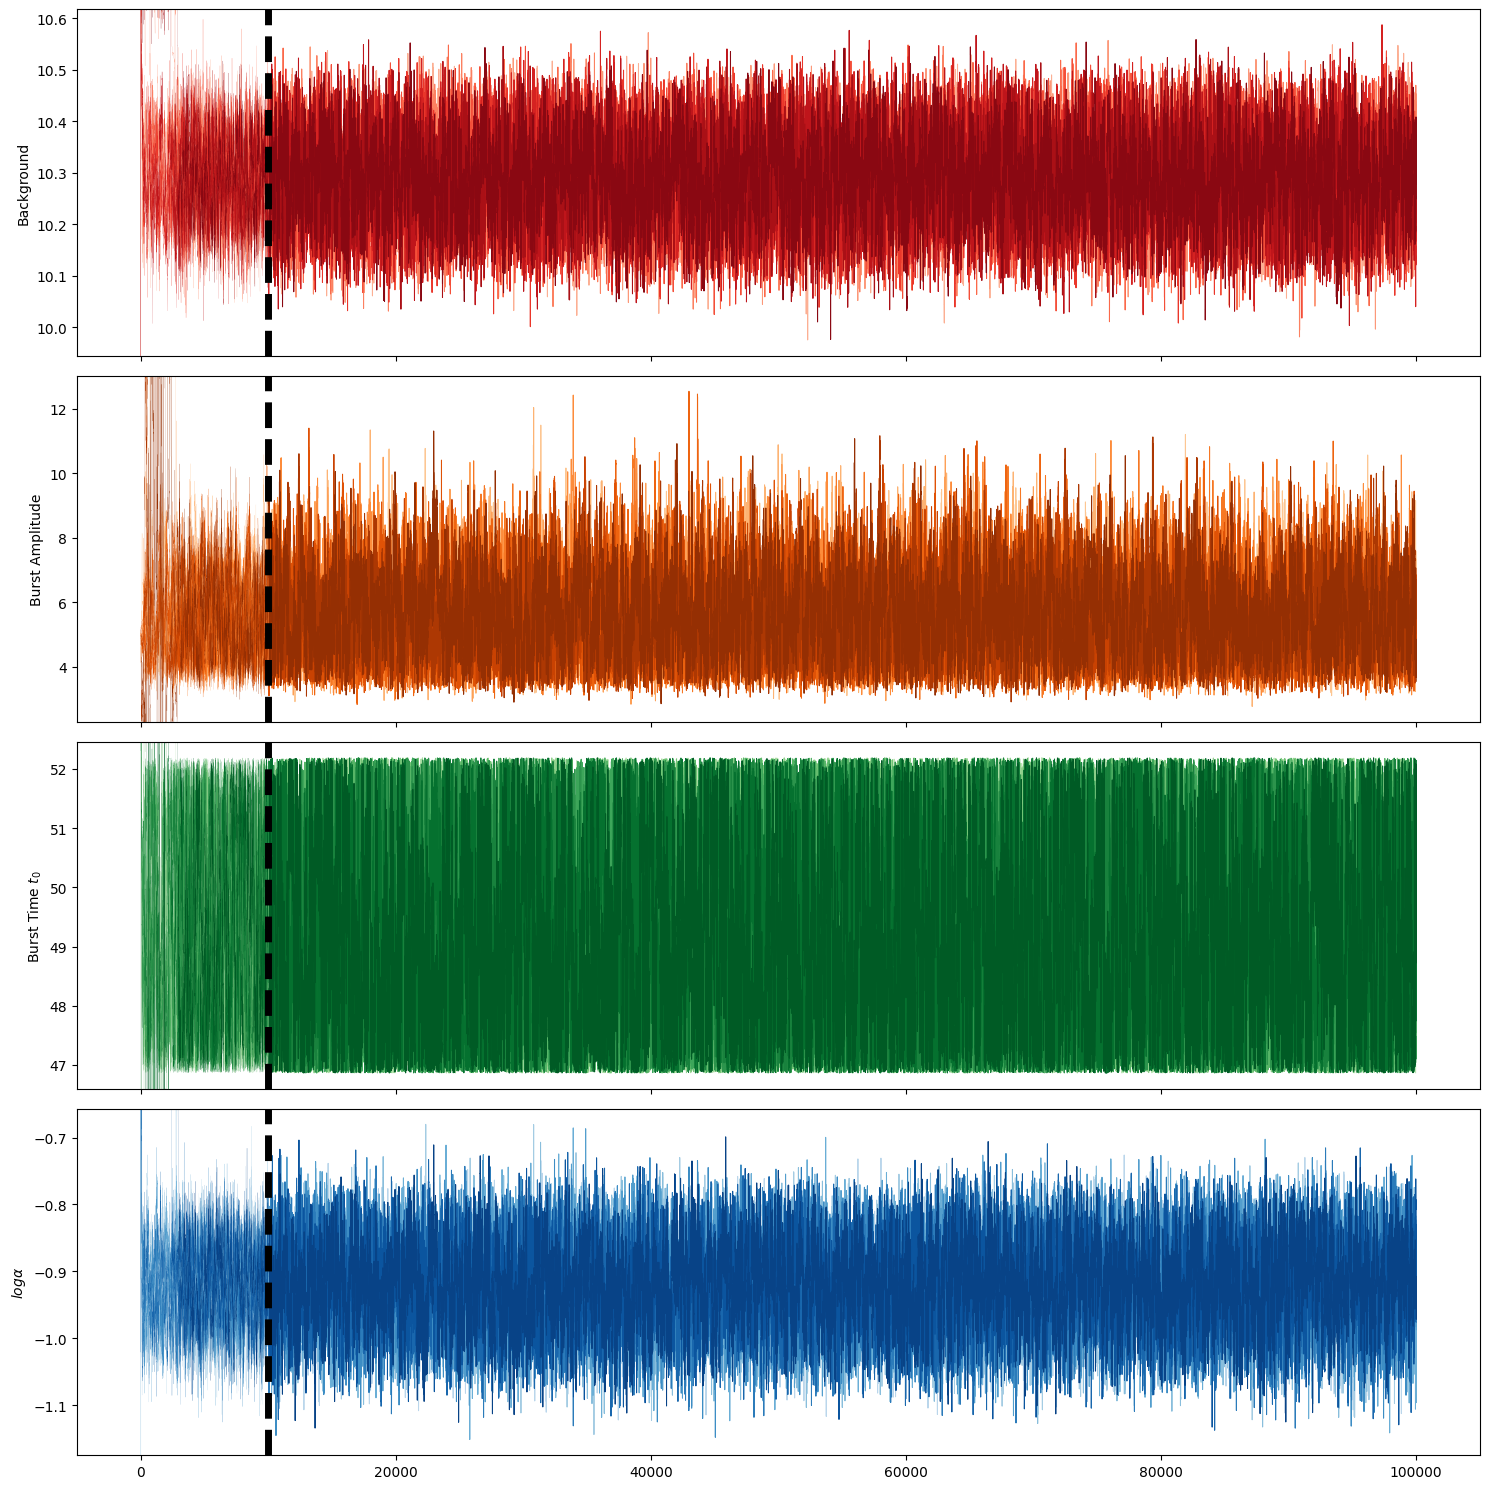

In [12]:
from numba import njit, float64

@njit(float64(float64, float64[:]))
def Model(t, params):
    bkg, bAmpl, t0, logalpha = params
    if t < t0: return bkg
    alpha = 10**logalpha
    return bkg + bAmpl*np.exp(-alpha*(t-t0))

@njit(float64(float64))
def Prior_bkg(x): return 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )

@njit(float64(float64))
def Prior_bAmpl(x): return 0 if x <0 else 0 if x> 50 else 1/50  #stats.uniform(loc=0, scale=50 )

@njit(float64(float64))
def Prior_t0(x): return 0 if x <0 else 0 if x>100 else 1/100 #stats.uniform(loc=0, scale=100)

@njit(float64(float64))
def Prior_logalpha(lnx): return 0 if lnx < -5 else 0 if lnx>5 else 1/10 # return  stats.loguniform(a=1e-5, b=1e5).pdf(x)

@njit(float64(float64[:]))
def logPrior(params):
    bkg, bAmpl, t0, logalpha = params
    y = np.log10(Prior_bkg(bkg)) + np.log10(Prior_bAmpl(bAmpl)) + np.log10(Prior_t0(t0)) + np.log10(Prior_logalpha(logalpha))
    if np.isnan(y) == True: return -np.inf
    return y

@njit(float64(float64[:]))
def logLikelihood(params):
    logL = 0
    for t, f, rms in zip(time, flux, yerr):
        logL = logL - ( f - Model(t, params) )**2 / 2*np.pi/rms**2
    if np.isnan(logL) == True: return -np.inf
    return logL

@njit(float64(float64[:]))
def logPosterior(params):
    if np.isnan(logPrior(params)) == True: return -np.inf
    return logPrior(params) + logLikelihood(params)

import emcee
ndim = 4; nwalkers = 10; nsteps=100000
logalphas = np.linspace(-5.0, 5.0, nwalkers)
from scipy import stats
starting_guess = [ [stats.norm(11, 3).rvs(1)[0], stats.norm(5, 0.1).rvs(1)[0], stats.norm(57, 3).rvs(1)[0], logalphas[_] ] 
                    for _ in range(nwalkers) ]

sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior)
_ = sampler.run_mcmc(starting_guess, nsteps, progress=True)

burn = 10000  # "burn-in" period to let chains stabilize
### I am being very drastic, I could probably spare some more chain.
print('RAW (nWalkers, nSteps, nDim)', np.shape(sampler.chain))
import seaborn as sns
colors =[sns.color_palette('Reds',    n_colors=nwalkers+3, as_cmap=False)[3:],
         sns.color_palette('Oranges', n_colors=nwalkers+3, as_cmap=False)[3:],
         sns.color_palette('Greens',  n_colors=nwalkers+3, as_cmap=False)[3:],
         sns.color_palette('Blues',   n_colors=nwalkers+3, as_cmap=False)[3:] ]

fig, axs = plt.subplots(ndim, figsize=(15, 15), tight_layout=True, sharex=True, sharey=False)
for i in range(nwalkers): ### Overlapping each walker chain on the same pad ### I removed the burn-in phase, so that the lw is different
    for j in range(ndim): ### One pad contains the chains sampling each parameter 
        axs[j].plot(np.arange(burn, nsteps, 1), sampler.chain[i][burn:,j], c=colors[j][i], lw=0.75)

for ax in axs: 
    ax.axvline(burn, lw=5, zorder=15, ls='--', c='k')
    ax.set_ylim(ax.get_ylim())
    
for i in range(nwalkers): ### Same thing as above, from i=0 to i=iBurn-in.
    for j in range(ndim): ### I am adding the burn-in part here, just to change the lw.
        axs[j].plot(np.arange(0, burn, 1), sampler.chain[i][:burn,j], c=colors[j][i], lw=0.1)   
        
yLabels = ['Background', 'Burst Amplitude', r'Burst Time $t_{0}$', r'$log \alpha$']
for j, label in enumerate(yLabels): 
    axs[j].set_ylabel(label)

The chain is indeed self-similar and it is mixing well.
The transient period looks very short, but I choose a very conservative approach
Therefore, I trim a lot of the initial part chain (= 'burn' int parameter) 

### Next Steps
"What is the autocorrelation length?" -> Pick the largest one -> Take 3x times as much as that
I pick the largest autocorrelation length, and extract one chain element for every Tau elements
I am therefore left with N_trimmed samples ~ ( nChain - nBurn ) / MaxTau

Autocorrelation Times [445.36825642 382.44407354 374.1120856  784.32687697] -> Thinning 2352


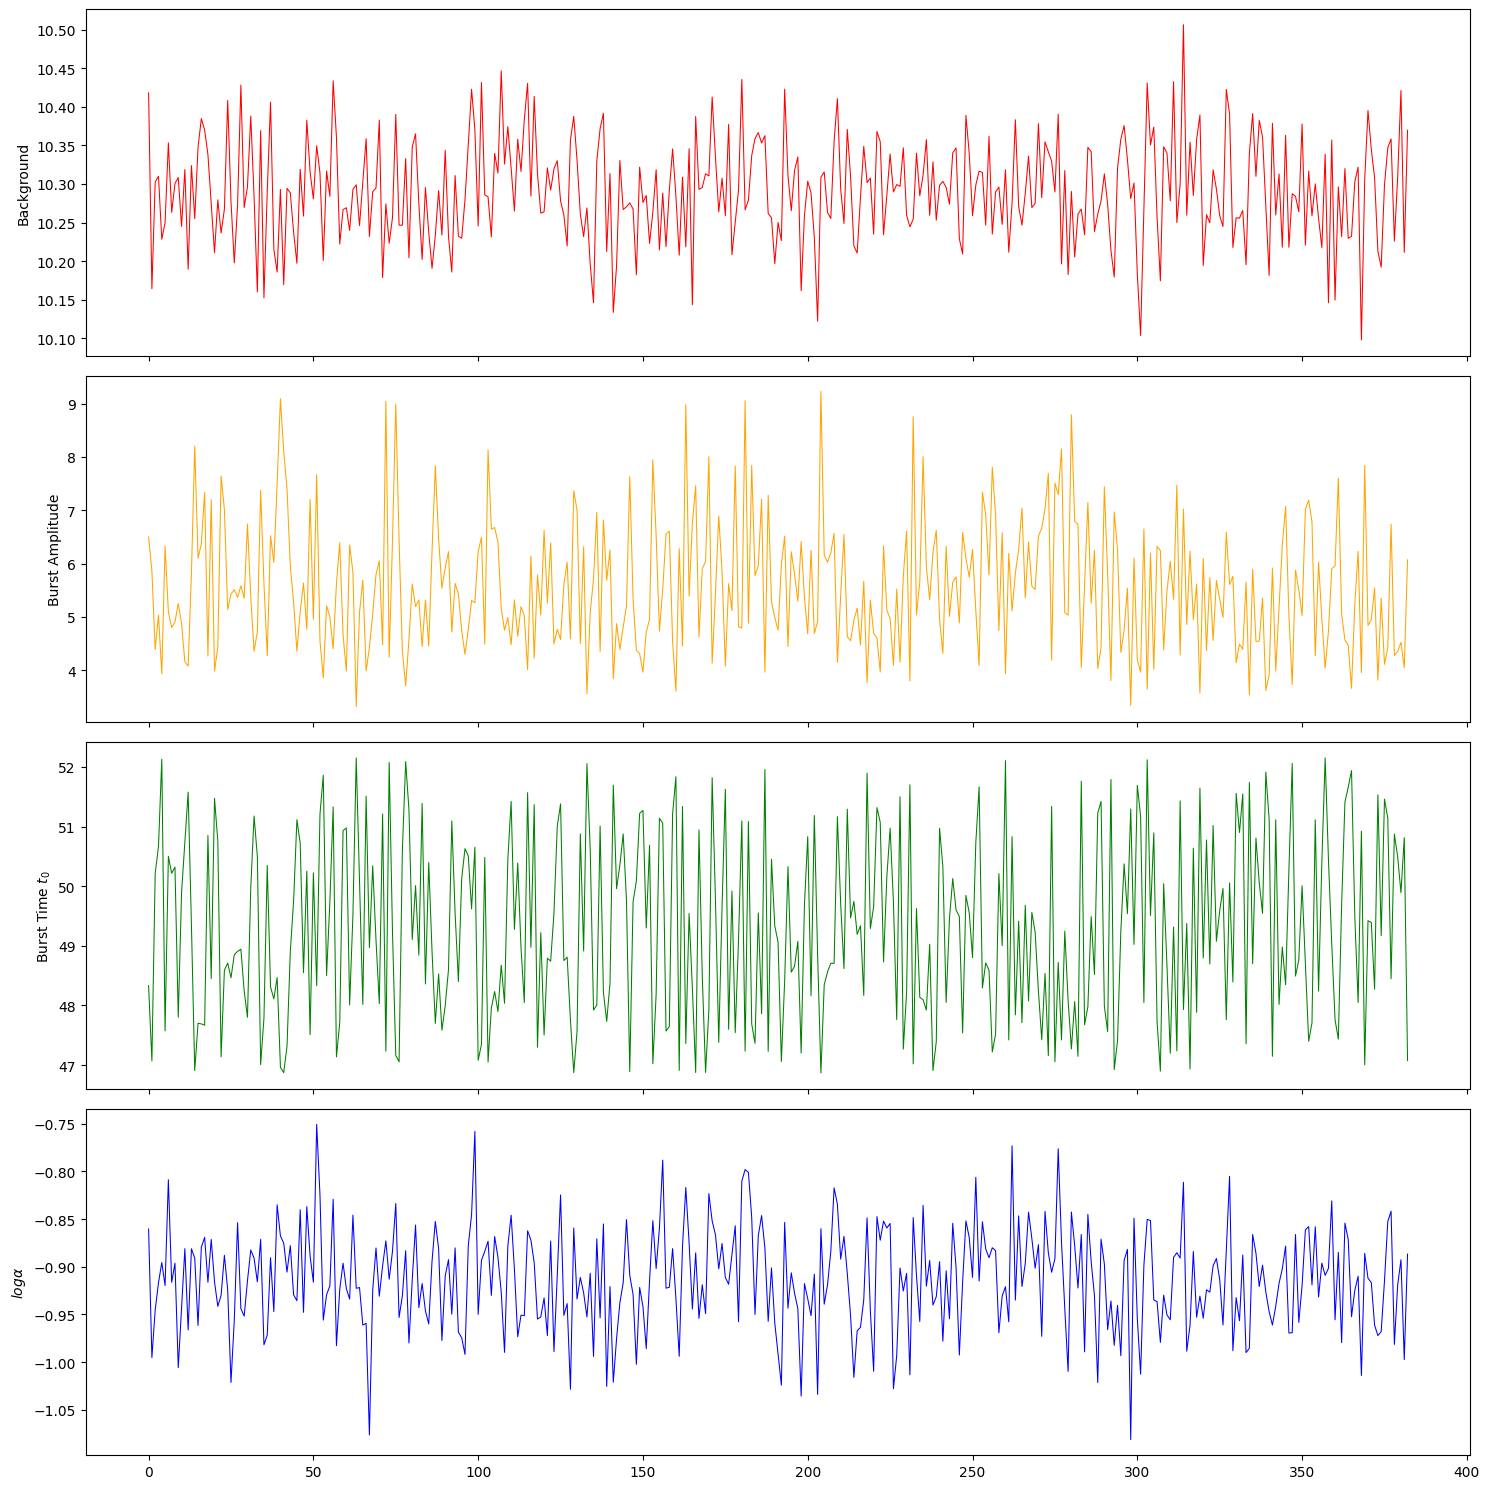

In [14]:
### Squeezing the chains together, plotting one final chain per parameter, per pad.
tau  = sampler.get_autocorr_time()
thin = [ int(tt+1) for tt in tau ]
thin = [ int( np.around(tt, 0) ) for tt in tau]
maxTau = 3*np.max(thin)
print('Autocorrelation Times', tau, '-> Thinning', maxTau)
emcee_flat = sampler.get_chain(discard=burn, flat=True)

fig, axs = plt.subplots(ndim, figsize=(15, 15), tight_layout=True, sharex=True, sharey=False)
colors   = ['red', 'orange', 'green', 'blue']
for j in range(ndim):
    axs[j].plot(np.arange(0, len(emcee_flat[::maxTau,j]), 1), emcee_flat[::maxTau, j], c=colors[j], lw=0.75)

yLabels = ['Background', 'Burst Amplitude', r'Burst Time $t_{0}$', r'$log \alpha$']
for j, label in enumerate(yLabels): 
    axs[j].set_ylabel(label)

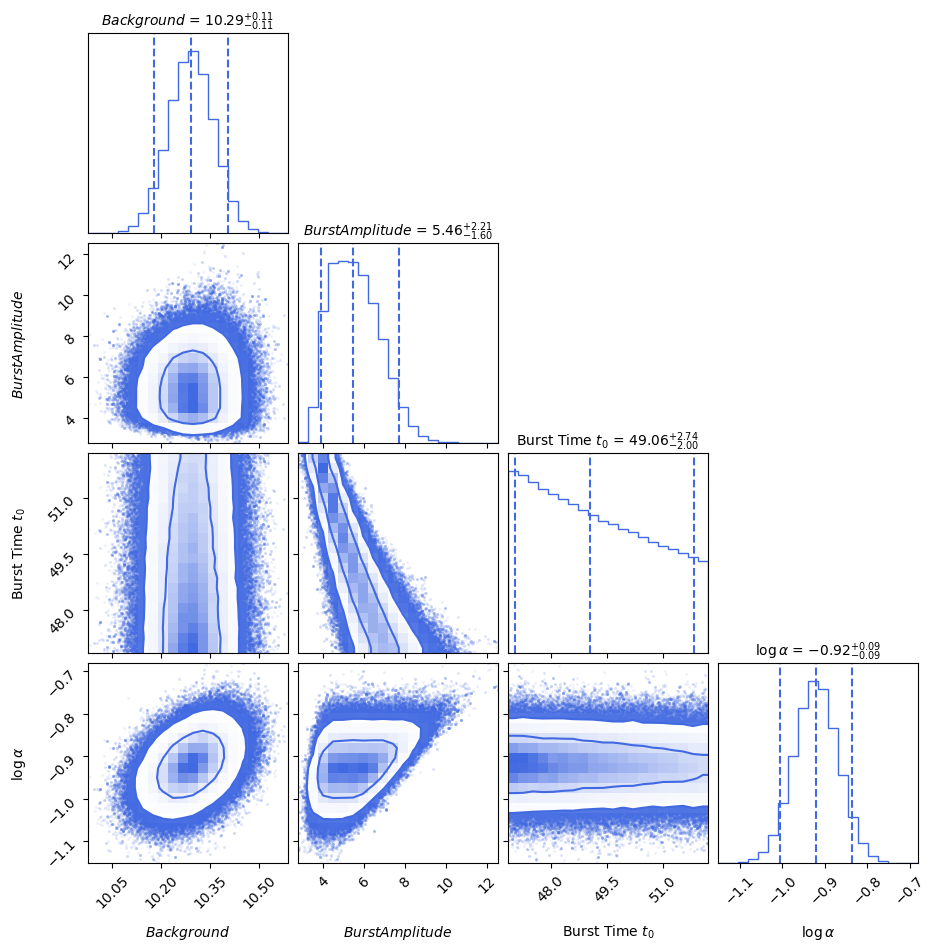

In [17]:
import corner
figure = corner.corner(np.asarray(emcee_flat), quantiles=[0.05, 0.5, 0.95], levels=(0.68, 0.95), #[0.16, 0.5, 0.84],
                       labels=[ '$Background$', '$Burst Amplitude$', r'Burst Time $t_{0}$', r"$\log \alpha$"], 
                       show_titles=True, title_kwargs={"fontsize": 10}, color='royalblue')

The t0 prior was very broad, but now it looks well-constrained
Moreover, one can clearly see a correlation between A and t0, which is NEGATIVE

In fact, if t0 decreases, the burst amplitude A must increase to "compensate". The noise in the plots is also well-constrained.

In [19]:
### Ogni sample nella posterior è possible realization. A questo punto, hai una DISTRIBUTION of MODELS.
# Randomly pick some models out of your distribution: 
### Extract some summary statistics: marginalized distribution, express median \pm %iles for every model parameter

# CAVEAT: it is VERY WRONG to pick THOSE guys that I just printed, and plot them as the BEST model. QUESTE SONO LE MEDIE DELLA MARGINALIZED DISTRIBUTION

### THE MEDIANS OF THE MARGINALIZED DISTRIBUTIONS HAVE NOTHING TO DO WITH THE 4D MODEL THAT I AM TREATING.

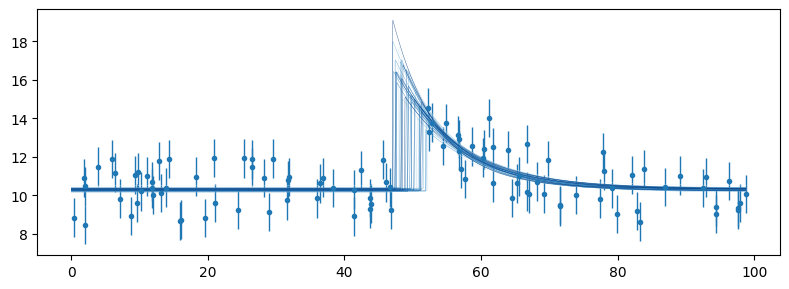

In [33]:
bkg, bAmpl, t0, lnalpha = emcee_flat.T
idx = np.random.randint(0, len(bkg), 50)


fig, axs = plt.subplots(tight_layout=True, figsize=(8,3))
axs.errorbar(time, flux, yerr=yerr, marker='.', lw=0.0, elinewidth=1); 
cmap = sns.color_palette('Blues', n_colors=len(idx)+3, as_cmap=False)[2:]
for i, id in enumerate(idx):
    params = emcee_flat[id]#[0]
    #print(params)
    axs.plot(np.linspace(0, max(time), 1000), [Model(t, params) for t in np.linspace(0, max(time), 1000)], c=cmap[i], lw=0.25)

In [ ]:
# {A, b, t0, alpha} -> ONE posterior model
# estraiamo summary statistics? MAXIMUM A POSTERIORi, è un esempio.
# le mediane delle marginal non sono SBAGLIATE, solo che appartengono a spazi di dimensione DIVERSA.

## "Ho misurato un Burst con un'amplitude A": puoi presentare A con la mediana della marginalized.
## "Il modello del burst a 4 param è {median(A), median(b), ecc.} -> NON E' GIUSTO, E' COMPLETAMENTE SBAGLIATO

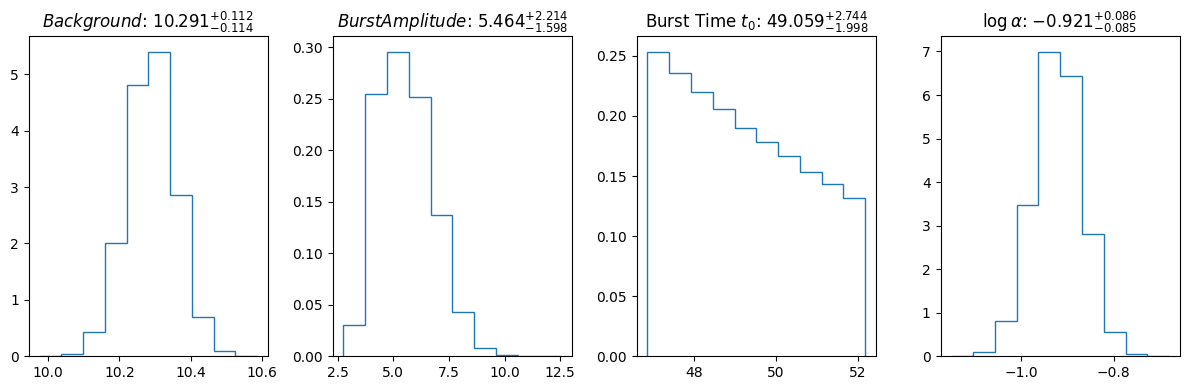

In [40]:
### bkg, bAmpl, t0, lnalpha = emcee_flat.T
fig, axs = plt.subplots(1,4, figsize=(12, 4), tight_layout=True)
labels=[ '$Background$', '$Burst Amplitude$', r'Burst Time $t_{0}$', r"$\log \alpha$"]
colors   = ['red', 'orange', 'green', 'blue']
i=0
for pars, label in zip( emcee_flat.T, labels ):
    mu = str(np.around(np.median(pars), 3))
    q5 = str(np.around(float(mu) - np.quantile(pars, 0.05), 3))
    q95= str(np.around(np.quantile(pars, 0.95)- float(mu), 3))
    string = label + r': $' + mu + '_{-' + q5 +'}^{+' + q95 + '}$'
    axs[i].hist(pars, histtype='step', density=True, facecolor=colors[i])
    axs[i].set_title(string)
    i+=1   